In [ ]:
import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 


In [4]:
df= pd.read_csv('/Users/pranesh/coding2/MachineLearningFrom0/datasets/spotify_millsongdata.csv')

In [5]:
df.head(100)

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...
...,...,...,...,...
95,ABBA,The Name Of The Game,/a/abba/the+name+of+the+game_20002863.html,"I've seen you twice, in a short time \r\nOnly..."
96,ABBA,The Piper,/a/abba/the+piper_20002946.html,They came from the hills \r\nAnd they came fr...
97,ABBA,The Visitors,/a/abba/the+visitors_20002864.html,I hear the doorbell ring and suddenly the pani...
98,ABBA,The Way Old Friends Do,/a/abba/the+way+old+friends+do_20002573.html,You and I can share the silence \r\nFinding c...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [7]:
df.isnull().sum()

artist    0
song      0
link      0
text      0
dtype: int64

In [8]:
top_artists = df['artist'].value_counts().head(10)
print(top_artists)

artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Cher                187
Alabama             187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [9]:
df = df.sample(10000)

In [10]:
df = df.drop('link', axis = 1).reset_index(drop = True)

In [11]:
df

,artist,song,text
0,Patsy Cline,Have You Ever Been Lonely,Have you ever been lonely have you ever been b...
1,Clash,Fingerpoppin',This here finger of mine \r\nIs gonna point t...
2,Bon Jovi,Ballad Of Youth,"(sambora, morolda) \r\n \r\nGrowing up today..."
3,Ray Charles,I Love You More Than I Ever Have,Don't you know I'm about as happy as I can be ...
4,Cher,Good Times,GOOD TIMES \r\nWriter Sonny Bono \r\n \r\nI...
...,...,...,...
9995,Loretta Lynn,Rated X,Well if you've been a married woman \r\nAnd t...
9996,Tori Amos,Josephine,Not tonight josephine. \r\nIn an army's stren...
9997,Indigo Girls,Draw The Line,You can write me a letter \r\nBut I wont tell...
9998,Hank Williams Jr.,Getting Over You,I sold my car to buy more wine \r\nI hocked m...


In [12]:
all_lyrics = " ".join(df['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lyrics)

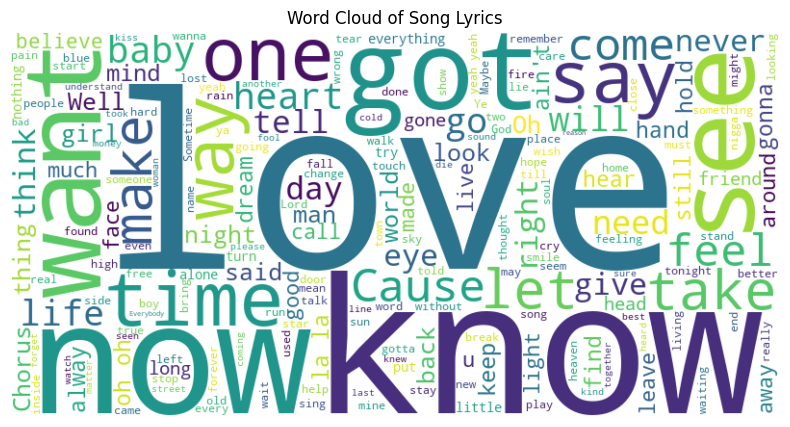

In [13]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Song Lyrics')
plt.show()


In [14]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/pranesh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pranesh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pranesh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))

In [16]:
def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [17]:
df['cleaned_text'] = df['text'].apply(preprocess_text)


In [18]:
df["cleaned_text"]

0       ever lonely ever blue ever loved someone love ...
1       finger mine gon na point beat right time finge...
2       sambora morolda growing today theres many moun...
3       dont know im happy cause made happy man took m...
4       good times writer sonny bono think got trouble...
                              ...                        
9995    well youve married woman things didnt seem wor...
9996    tonight josephine armys strength therein lies ...
9997    write letter wont tell oh send postcard baby w...
9998    sold car buy wine hocked watch ive lost track ...
9999    oh taste wine liquor womans tender kiss sure p...
Name: cleaned_text, Length: 10000, dtype: object

In [19]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [20]:
cosine_sin = cosine_similarity(tfidf_matrix, tfidf_matrix) 

In [21]:
def recommend_songs(song_name, cosine_sin = cosine_sin, df = df , top_n = 5):
    idx = df[df['song'].str.lower() == song_name.lower()].index
    if len(idx) ==0:
        return "Song not found in the dataset."
    idx = idx[0]
    
    sin_scores = list(enumerate(cosine_sin[idx]))
    sin_scores = sorted(sin_scores ,key = lambda x: x[1], reverse = True)
    sin_scores = sin_scores[1: top_n + 1]   
    
    song_indices = [i[0] for i in sin_scores]
    return df['song'].iloc[song_indices]